# Lab 6 — GAN для предсказания траекторий

- **Генератор** `G`: из растра сцены → будущая траектория 50×2;
- **Дискриминатор** `D`: история + траектория → real/fake;
- **Функция потерь генератора:** adversarial (обман D) + L1-регуляризация (стабилизирует GAN).

In [1]:
import os                          
import json     
import time                   
import matplotlib.pyplot as plt   
import numpy as np        

from pathlib import Path      

# --- PyTorch ---
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision.models import resnet18

# --- l5kit: данные, датасет, растеризация ---
from l5kit.data import ChunkedDataset, LocalDataManager
from l5kit.dataset import AgentDataset
from l5kit.rasterization import build_rasterizer

# --- l5kit: геометрия и отрисовка траекторий ---
from l5kit.geometry import transform_points
from l5kit.visualization import (PREDICTED_POINTS_COLOR, TARGET_POINTS_COLOR, draw_trajectory)

c:\Users\sadovets\Dev\BMSTU\IU1_ML\sem2\lab6\.venv\lib\site-packages\l5kit\dataset\select_agents.py:31: UserWarning: Windows detected. BLOSC_NOLOCK has not been set as it causes memory leaks on Windows.However, writing the mask with this config may be inconsistent.
  warnings.warn(


## 1. AgentDataset + PyTorch DataLoader

- `LocalDataManager` + `ChunkedDataset` — открытие `sample.zarr`;
- `build_rasterizer(cfg, dm)` — растеризатор по собранной конфигурации (`box_debug` — без карты);
- `AgentDataset(cfg, zarr, rasterizer)` — PyTorch-датасет: один элемент = один агент
  в один момент времени (растр + история + будущее);
- `DataLoader` — стандартный PyTorch: батчи, перемешивание.

In [2]:
POS_SCALE = 50.0      # нормировка координат: метры -> ~единицы (для стабильного обучения)
FUTURE_FRAMES = 50    # 50 кадров будущего = 5 секунд (из конфига cfg)

DATA_ROOT = Path("../data/raw").resolve()
FULL_DATA_ROOT = Path("D:/ML_datasets/lyft_data")

FULL_FILES = [
    "train.zarr.zip",
    "validate.zarr.zip",   
    "test.zarr.zip",       
]

if not DATA_ROOT.exists():
    DATA_ROOT = Path("data/raw").resolve()
assert (DATA_ROOT / "sample.zarr").exists(), f"Не найден sample.zarr в {DATA_ROOT}"

print("DATA_ROOT: ", DATA_ROOT)
print("FULL_DATA_ROOT: ", FULL_DATA_ROOT)

cfg = {
    "raster_params": {
        "raster_size": [224, 224], 
        "pixel_size": [0.5, 0.5],      
        "ego_center": [0.25, 0.5],  
        "map_type": "box_debug",        
        "filter_agents_threshold": 0.5, 
        "set_origin_to_bottom": False,
        "disable_traffic_light_faces": False,
        "dataset_meta_key": "meta.json",
    },
    "model_params": {
        "history_num_frames": 10, 
        "history_num_frames_ego": 10,
        "history_num_frames_agents": 10,
        "history_step_size": 1,
        "history_delta_time": 0.1,
        "future_num_frames": 50,
        "future_step_size": 1,
        "future_delta_time": 0.1,
        "step_time": 0.1,
        "render_ego_history": False,
    },
}

# print("cuda доступна:", torch.cuda.is_available())
# print("версия torch:", torch.__version__, "| cuda в сборке:", torch.version.cuda)
# device = "cuda" if torch.cuda.is_available() else "cpu"
print("RTX 5080 не поддерживается Python 3.8, так что - :(\n")
device = "cpu"


for key in ["train.zarr", "validate.zarr",
            "aerial_map/aerial_map.png", "semantic_map/semantic_map.pb"]:
    p = FULL_DATA_ROOT / key
    print(f"  {'OK ' if p.exists() else 'НЕТ!'}  {p}")

DATA_ROOT:  C:\Users\sadovets\Dev\BMSTU\IU1_ML\sem2\lab6\data\raw
FULL_DATA_ROOT:  D:\ML_datasets\lyft_data
RTX 5080 не поддерживается Python 3.8, так что - :(

  OK   D:\ML_datasets\lyft_data\train.zarr
  OK   D:\ML_datasets\lyft_data\validate.zarr
  OK   D:\ML_datasets\lyft_data\aerial_map\aerial_map.png
  OK   D:\ML_datasets\lyft_data\semantic_map\semantic_map.pb


! ОЧЕНЬ ВАЖНО ! - ВЫБОР ДАТАСЕТА (ПОЛНЫЙ ИЛИ ПРИМЕР)

In [3]:
# os.environ["L5KIT_DATA_FOLDER"] = str(DATA_ROOT)
os.environ["L5KIT_DATA_FOLDER"] = str(FULL_DATA_ROOT)

dm = LocalDataManager(None)

# zarr_dataset = ChunkedDataset(dm.require("sample.zarr")).open()
zarr_dataset = ChunkedDataset(dm.require("train.zarr")).open()

rasterizer = build_rasterizer(cfg, dm)
agent_dataset = AgentDataset(cfg, zarr_dataset, rasterizer)

print(f"Примеров: {len(agent_dataset)}")

Примеров: 22496709


In [4]:
BATCH_SIZE = 12

# DataLoader — итератор поверх датасета.
# Каждый раз, когда из него просят следующий элемент (next() или for batch in loader),
# он берёт BATCH_SIZE случайных примеров из agent_dataset,
# склеивает их по первой оси в батч и отдаёт словарь тензоров.

loader = DataLoader(agent_dataset, batch_size=BATCH_SIZE, shuffle=True) # num_workers=0

# iter(loader) — итератор, next(...) — взять ОДИН батч и посмотреть, что внутри.
batch = next(iter(loader))

in_channels = batch["image"].shape[1]   # = 22
history_frames = batch["history_positions"].shape[1]  # = 11

for k, v in batch.items():
    if hasattr(v, "shape"):
        print(f"{k:28s} {str(tuple(v.shape)):20s} {v.dtype}")

frame_index                  (12,)                torch.int64
image                        (12, 22, 224, 224)   torch.float32
target_positions             (12, 50, 2)          torch.float32
target_yaws                  (12, 50, 1)          torch.float32
target_velocities            (12, 50, 2)          torch.float32
target_availabilities        (12, 50)             torch.float32
history_positions            (12, 11, 2)          torch.float32
history_yaws                 (12, 11, 1)          torch.float32
history_velocities           (12, 10, 2)          torch.float32
history_availabilities       (12, 11)             torch.float32
world_to_image               (12, 3, 3)           torch.float64
raster_from_agent            (12, 3, 3)           torch.float64
raster_from_world            (12, 3, 3)           torch.float64
agent_from_world             (12, 3, 3)           torch.float64
world_from_agent             (12, 3, 3)           torch.float64
centroid                     (12, 2)      

- `image` — растр сцены: `(BATCH_SIZE, 22, 224, 224)` — 11 кадров (история + текущий) × 2 канала
  (агенты + эго) для `box_debug`;
- `history_positions` — `(BATCH_SIZE, 11, 2)`, прошлое агента в его системе координат (x, y), м;
- `target_positions` — `(BATCH_SIZE, 50, 2)`, будущее агента;
- `target_availabilities` — `(BATCH_SIZE, 50)`, маска валидных точек будущего.

## 2. Модель

Задача: по картинке сцены предсказать будущую траекторию агента (50 точек × 2 координаты)

### Общая схема -> GAN

### Вариант генератора №1: `VAEGenerator`

- `ImageEncoder` — CNN-энкодер картинки: 3 свёртки → вектор признаков.
- **VAE-энкодер** — MLP: история + настоящее будущее → `mu`, `logvar` (по 16 чисел) —
  параметры распределения срытого слоя`z`.
- **декодер** — MLP: [признаки картинки (128) + история (22) + z (16)] → траектория (50×2).
  На предсказании `z ~ N(0, 1)` — каждый новый `z` даёт другой вариант траектории.

### Вариант генератора №2: `ResNetGenerator` (прямая регрессия)

Растр (22, 224, 224) → **ResNet-18** (свёрточный энкодер из torchvision, обучаем с нуля;
первый слой заменён под 22 канала вместо RGB) → вектор признаков (1000) →
линейная голова → траектория (50×2).

### Дискриминатор `TrajectoryDiscriminator`

MLP: [история (22) + траектория (100)] → один логит «настоящая / подделка».

### Функции потерь

- **дискриминатор**: BCE — бинарная кросс-энтропия (настоящие → 1, подделки → 0);
- **генератор**: adversarial (обмануть D) + `L1_WEIGHT` × L1 до настоящей траектории;
  у VAE дополнительно `KL_WEIGHT` × KL-дивергенция (регуляризация латентного пространства).

In [5]:
class ImageEncoder(nn.Module):
    # Свёрточный энкодер растра -> вектор признаков (нужен VAE-генератору)
    def __init__(self, in_channels, feat_dim=128):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, 5, 2, 2), nn.ReLU(),   # 224 -> 112
            nn.Conv2d(32, 64, 5, 2, 2), nn.ReLU(),            # 112 -> 56
            nn.Conv2d(64, 128, 5, 2, 2), nn.ReLU(),           # 56 -> 27
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),            # -> 128 чисел
        )
        self.fc = nn.Linear(128, feat_dim)

    def forward(self, x):
        return self.fc(self.conv(x))

class ResNetGenerator(nn.Module):
    # Вариант A: растр сцены -> будущая траектория (50 x 2), прямая регрессия
    def __init__(self, in_channels: int, future_frames: int = 50):
        super().__init__()
        backbone = resnet18(weights=None)
        # дефолтный conv1 ждёт 3 канала (RGB), у нас 22 (11 кадров x 2) — заменяем
        backbone.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.backbone = backbone              # выдаёт вектор признаков размера 1000
        self.future_frames = future_frames
        self.head = nn.Linear(1000, future_frames * 2)

    def forward(self, image):
        return self.head(self.backbone(image)).view(-1, self.future_frames, 2)

class VAEGenerator(nn.Module):
    # Вариант B: условный VAE: (растр, история, z) -> будущая траектория (50 x 2)
    def __init__(self, in_channels, history_frames, future_frames, z_dim=16, feat_dim=128):
        super().__init__()
        self.z_dim = z_dim
        self.img_enc = ImageEncoder(in_channels, feat_dim)
        # VAE-энкодер: история + будущее -> mu, logvar латентного кода z
        enc_in = (history_frames + future_frames) * 2
        self.enc = nn.Sequential(nn.Linear(enc_in, 256), nn.ReLU(),
                                 nn.Linear(256, 256), nn.ReLU())
        self.mu = nn.Linear(256, z_dim)
        self.logvar = nn.Linear(256, z_dim)
        # декодер: признаки растра + история + z -> будущее
        dec_in = feat_dim + history_frames * 2 + z_dim
        self.dec = nn.Sequential(
            nn.Linear(dec_in, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, future_frames * 2),
        )
        self.future_frames = future_frames

    def encode(self, history, future):
        h = self.enc(torch.cat([history.flatten(1), future.flatten(1)], 1))
        return self.mu(h), self.logvar(h)

    def decode(self, image, history, z):
        x = torch.cat([self.img_enc(image), history.flatten(1), z], 1)
        return self.dec(x).view(-1, self.future_frames, 2)

    def forward(self, image, history, future=None):
        if future is not None:   # режим ОБУЧЕНИЯ: z из энкодера (репараметризация)
            mu, logvar = self.encode(history, future)
            z = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
            return self.decode(image, history, z), mu, logvar
        # режим ПРЕДСКАЗАНИЯ: будущего нет -> z ~ N(0, 1)
        z = torch.randn(image.shape[0], self.z_dim, device=image.device)
        return self.decode(image, history, z)

class TrajectoryDiscriminator(nn.Module):
    # История + траектория -> один логит (настоящая / подделка)
    def __init__(self, history_frames: int, future_frames: int):
        super().__init__()
        in_dim = (history_frames + future_frames) * 2  # каждая точка = (x, y)
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
        )

    def forward(self, history, future):
        # flatten(1): (B, T, 2) -> (B, T*2); склеиваем историю и будущее в один вектор
        x = torch.cat([history.flatten(1), future.flatten(1)], dim=1)
        return self.net(x).squeeze(1)

In [6]:
torch.manual_seed(42)

gen_resnet  = ResNetGenerator(in_channels, FUTURE_FRAMES).to(device)
disc_resnet = TrajectoryDiscriminator(history_frames, FUTURE_FRAMES).to(device)
gen_vae     = VAEGenerator(in_channels, history_frames, FUTURE_FRAMES).to(device)
disc_vae    = TrajectoryDiscriminator(history_frames, FUTURE_FRAMES).to(device)

opt_G  = torch.optim.Adam(gen_resnet.parameters(), lr=1e-4)
opt_D  = torch.optim.Adam(disc_resnet.parameters(), lr=1e-4)
opt_V  = torch.optim.Adam(gen_vae.parameters(), lr=1e-4)
opt_Dv = torch.optim.Adam(disc_vae.parameters(), lr=1e-4)

# --- функции потерь ---
bce = nn.BCEWithLogitsLoss()    
l1 = nn.L1Loss(reduction="none")

for name, m in [("ResNetGenerator", gen_resnet), ("VAEGenerator", gen_vae),
                ("TrajectoryDiscriminator", disc_resnet)]:
    print(f"{name:26s} параметров: {sum(p.numel() for p in m.parameters()) / 1e6:.2f}M")

ResNetGenerator            параметров: 11.85M
VAEGenerator               параметров: 0.53M
TrajectoryDiscriminator    параметров: 0.10M


In [7]:
print("ВХОДЫ/ВЫХОДЫ (на один пример):")
print(f"  gen_resnet вход:  растр image ({in_channels}, 224, 224) = {in_channels * 224 * 224:,} чисел")
print(f"  gen_vae    вход:  тот же растр + история (11, 2) + z (16)")
print(f"  генераторы выход: траектория (50, 2) = 100 чисел")
print(f"  дискриминатор вход:  история (11, 2) + траектория (50, 2) -> {(11 + 50) * 2} числа")
print(f"  дискриминатор выход: 1 число (логит real/fake)")

ВХОДЫ/ВЫХОДЫ (на один пример):
  gen_resnet вход:  растр image (22, 224, 224) = 1,103,872 чисел
  gen_vae    вход:  тот же растр + история (11, 2) + z (16)
  генераторы выход: траектория (50, 2) = 100 чисел
  дискриминатор вход:  история (11, 2) + траектория (50, 2) -> 122 числа
  дискриминатор выход: 1 число (логит real/fake)


## 3. Обучение

- `NUM_STEPS` — количество шагов. Шаг = один батч
- `BATCH_SIZE = 12` — сколько примеров в шаге
- `lr = 1e-4` — шаг Adam
- `L1_WEIGHT = 10` — во сколько раз «близость к правде» важнее «обмана D».
  Меньше 1 — GAN вырождается в "правдоподобный мусор"; больше 100 — D почти не влияет.
- `KL_WEIGHT = 0.1` — вес KL-члена у VAE (beta в терминах beta-VAE). 
    Больше 1 — латентный код «выключается» (posterior collapse); 0.1 — мягкая регуляризация;
- `POS_SCALE = 50` — нормировка координат (метры -> ~единицы) для стабильности градиентов.
- `CHECKPOINT_EVERY = 500` — чекпоинт: если при обучении что-то упадёт, веса не пропадут.

In [8]:
NUM_STEPS_RESNET = 1000
NUM_STEPS_VAE    = 2500   # VAE в 5-10 раз быстрее — можно больше
# NUM_STEPS_RESNET = 50
# NUM_STEPS_VAE    = 50   # VAE в 5-10 раз быстрее — можно больше
 
L1_WEIGHT = 10.0    
KL_WEIGHT = 0.1     
SAVE_EVERY = 500 

CHECKPOINT_EVERY = 500

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

In [9]:
losses_G, losses_D, losses_adv, losses_l1 = [], [], [], []
it = iter(loader)

for step in range(NUM_STEPS_RESNET):
    batch = next(it, None)
    if batch is None:        # данные кончились — начинаем проход заново
        it = iter(loader)
        batch = next(it)

    image = batch["image"].float().to(device)
    history = batch["history_positions"].float().to(device) / POS_SCALE
    target = batch["target_positions"].float().to(device) / POS_SCALE
    avail = batch["target_availabilities"].float().to(device).unsqueeze(-1)
    B = image.shape[0]  # реальный размер батча (последний может быть меньше)

    # --- шаг дискриминатора ---
    with torch.no_grad():       # генератор здесь не обучаем
        fake = gen_resnet(image)
    loss_D = 0.5 * (
        bce(disc_resnet(history, target), torch.ones(B, device=device))   # real -> 1
        + bce(disc_resnet(history, fake), torch.zeros(B, device=device))  # fake -> 0
    )
    opt_D.zero_grad()
    loss_D.backward()
    opt_D.step()

    # --- шаг генератора ---
    fake = gen_resnet(image)
    adv_loss = bce(disc_resnet(history, fake), torch.ones(B, device=device))  # обмануть D
    l1_loss = (l1(fake, target) * avail).mean()
    loss_G = adv_loss + L1_WEIGHT * l1_loss
    opt_G.zero_grad()
    loss_G.backward()
    opt_G.step()

    losses_G.append(loss_G.item())
    losses_D.append(loss_D.item())
    losses_adv.append(adv_loss.item())
    losses_l1.append(l1_loss.item())

    if step % 100 == 0:
        print(f"step {step:6d} | D {loss_D.item():.3f} | "
              f"G {loss_G.item():.3f} (adv {adv_loss.item():.3f}, l1 {l1_loss.item():.3f})")
    if step % CHECKPOINT_EVERY == 0 or step == NUM_STEPS_RESNET - 1:  # страховочное сохранение
        torch.save(gen_resnet.state_dict(), MODELS_DIR / "generator_resnet.pth")
        torch.save(disc_resnet.state_dict(), MODELS_DIR / "discriminator_resnet.pth")

# лоссы в файл — ноутбук 03 построит по ним кривые без переобучения
np.savez(MODELS_DIR / "losses_resnet.npz",
         total=losses_G, disc=losses_D, adv=losses_adv, l1=losses_l1)
print("ResNet-GAN обучен, веса и лоссы сохранены")

step      0 | D 0.697 | G 2.435 (adv 0.660, l1 0.177)
step    100 | D 0.703 | G 1.355 (adv 0.654, l1 0.070)
step    200 | D 0.692 | G 1.119 (adv 0.667, l1 0.045)
step    300 | D 0.685 | G 1.332 (adv 0.687, l1 0.065)
step    400 | D 0.672 | G 1.233 (adv 0.718, l1 0.051)
step    500 | D 0.675 | G 1.142 (adv 0.701, l1 0.044)
step    600 | D 0.690 | G 1.225 (adv 0.744, l1 0.048)
step    700 | D 0.728 | G 1.335 (adv 0.626, l1 0.071)
step    800 | D 0.652 | G 1.321 (adv 0.715, l1 0.061)
step    900 | D 0.632 | G 1.364 (adv 0.676, l1 0.069)
ResNet-GAN обучен, веса и лоссы сохранены


In [10]:
losses_V, losses_Dv, losses_recon, losses_kl = [], [], [], []
it = iter(loader)

for step in range(NUM_STEPS_VAE):
    batch = next(it, None)
    if batch is None:
        it = iter(loader)
        batch = next(it)

    image = batch["image"].float().to(device)
    history = batch["history_positions"].float().to(device) / POS_SCALE
    target = batch["target_positions"].float().to(device) / POS_SCALE
    avail = batch["target_availabilities"].float().to(device).unsqueeze(-1)
    B = image.shape[0]

    # --- шаг дискриминатора: подделка = предсказание со случайным z ---
    with torch.no_grad():
        fake = gen_vae(image, history)
    loss_Dv = 0.5 * (
        bce(disc_vae(history, target), torch.ones(B, device=device))
        + bce(disc_vae(history, fake), torch.zeros(B, device=device))
    )
    opt_Dv.zero_grad()
    loss_Dv.backward()
    opt_Dv.step()

    # --- шаг генератора: реконструкция + KL + adversarial ---
    recon, mu, logvar = gen_vae(image, history, target)      # z из энкодера
    recon_loss = (l1(recon, target) * avail).mean()
    kl_loss = (-0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(1)).mean()
    adv_loss = bce(disc_vae(history, recon), torch.ones(B, device=device))
    loss_V = L1_WEIGHT * recon_loss + KL_WEIGHT * kl_loss + adv_loss
    opt_V.zero_grad()
    loss_V.backward()
    opt_V.step()

    losses_V.append(loss_V.item())
    losses_Dv.append(loss_Dv.item())
    losses_recon.append(recon_loss.item())
    losses_kl.append(kl_loss.item())

    if step % 100 == 0:
        print(f"step {step:6d} | D {loss_Dv.item():.3f} | "
              f"V {loss_V.item():.3f} (recon {recon_loss.item():.3f}, kl {kl_loss.item():.3f})")
    if step % CHECKPOINT_EVERY == 0 or step == NUM_STEPS_VAE - 1:
        torch.save(gen_vae.state_dict(), MODELS_DIR / "generator_vae.pth")
        torch.save(disc_vae.state_dict(), MODELS_DIR / "discriminator_vae.pth")

np.savez(MODELS_DIR / "losses_vae.npz",
         total=losses_V, disc=losses_Dv, recon=losses_recon, kl=losses_kl)
print("VAE-GAN обучен, веса и лоссы сохранены")

step      0 | D 0.694 | V 1.073 (recon 0.039, kl 0.015)
step    100 | D 0.646 | V 1.419 (recon 0.069, kl 0.008)
step    200 | D 0.591 | V 1.643 (recon 0.076, kl 0.105)
step    300 | D 0.565 | V 1.261 (recon 0.044, kl 2.614)
step    400 | D 0.647 | V 1.014 (recon 0.027, kl 1.060)
step    500 | D 0.679 | V 1.099 (recon 0.037, kl 1.155)
step    600 | D 0.579 | V 1.226 (recon 0.054, kl 1.911)
step    700 | D 0.656 | V 1.013 (recon 0.024, kl 1.320)
step    800 | D 0.624 | V 0.980 (recon 0.032, kl 1.291)
step    900 | D 0.499 | V 1.131 (recon 0.029, kl 1.912)
step   1000 | D 0.494 | V 1.053 (recon 0.029, kl 1.776)
step   1100 | D 0.599 | V 1.088 (recon 0.019, kl 0.867)
step   1200 | D 0.549 | V 1.190 (recon 0.041, kl 1.589)
step   1300 | D 0.691 | V 0.904 (recon 0.029, kl 1.137)
step   1400 | D 0.684 | V 0.930 (recon 0.023, kl 1.187)
step   1500 | D 0.654 | V 0.903 (recon 0.016, kl 0.958)
step   1600 | D 0.679 | V 0.877 (recon 0.018, kl 0.868)
step   1700 | D 0.608 | V 0.726 (recon 0.008, kl

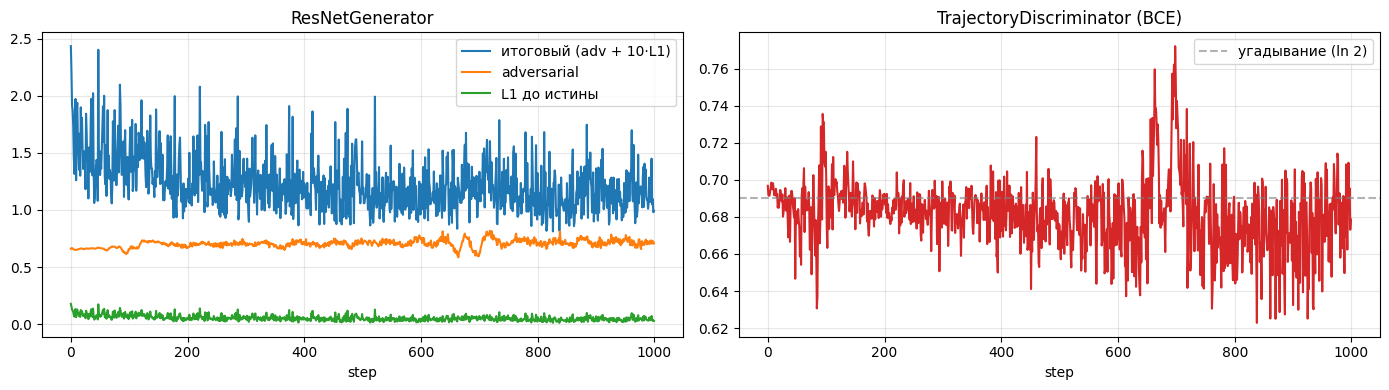

In [11]:
# Кривые ResNet-GAN
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(losses_G, label="итоговый (adv + 10·L1)", color="tab:blue")
ax1.plot(losses_adv, label="adversarial", color="tab:orange")
ax1.plot(losses_l1, label="L1 до истины", color="tab:green")
ax1.set_title("ResNetGenerator") 
ax1.set_xlabel("step") 
ax1.legend() 
ax1.grid(alpha=0.3)

ax2.plot(losses_D, color="tab:red")
ax2.axhline(0.69, ls="--", c="gray", alpha=0.6, label="угадывание (ln 2)")
ax2.set_title("TrajectoryDiscriminator (BCE)") 
ax2.set_xlabel("step"); 
ax2.legend() 
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(MODELS_DIR / "curves_resnet.png", dpi=120)
plt.show()

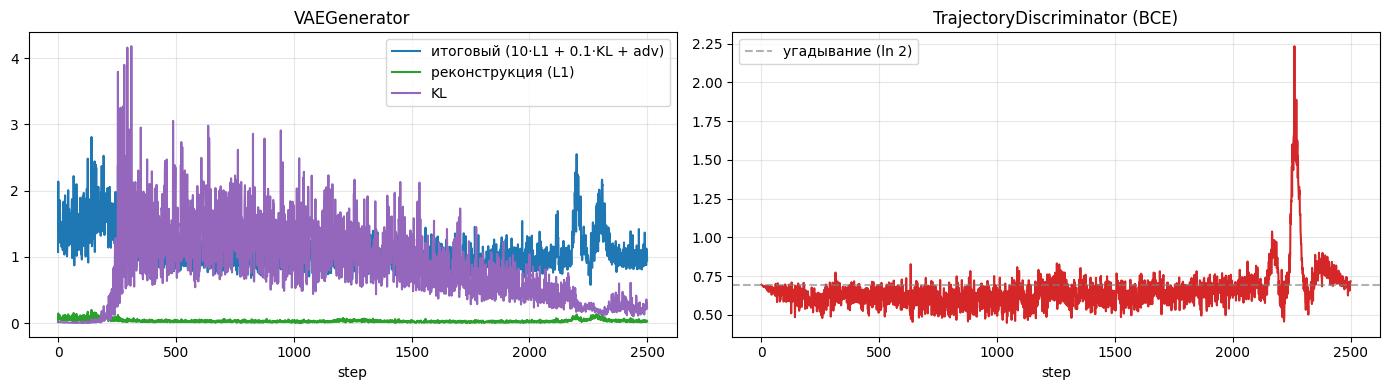

In [12]:
# Кривые VAE-GAN
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(losses_V, label="итоговый (10·L1 + 0.1·KL + adv)", color="tab:blue")
ax1.plot(losses_recon, label="реконструкция (L1)", color="tab:green")
ax1.plot(losses_kl, label="KL", color="tab:purple")
ax1.set_title("VAEGenerator") 
ax1.set_xlabel("step") 
ax1.legend() 
ax1.grid(alpha=0.3)

ax2.plot(losses_Dv, color="tab:red")
ax2.axhline(0.69, ls="--", c="gray", alpha=0.6, label="угадывание (ln 2)")
ax2.set_title("TrajectoryDiscriminator (BCE)")
ax2.set_xlabel("step")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(MODELS_DIR / "curves_vae.png", dpi=120)
plt.show()

**Как читать строку `step 20 | D 0.62 | G 4.31 (adv 0.71, l1 0.36)`:**

- `D` — функция потерь дискриминатора (Бинарная кросс-энтропия, BCE). Стартует около **0.69**. Падает → D научился отличать. Если упал почти в 0 — D слишком силён, G перестанет получать полезный сигнал.
- `adv` — насколько G обманывает D (та же шкала, ~0.69 = D не отличает подделку —
- `G` — функция потерь генератора = `adv + l1 · 1e1 `, где
  для генератора это хорошо).
- `l1` — среднее расстояние до настоящей траектории в **нормированных** единицах
  (мы делили координаты на 50 м, так что l1 = 0.36 ≈ 18 м средней ошибки).

## 4. Проверка

Пример #1685: история 6.5 м, будущее 41.7 м


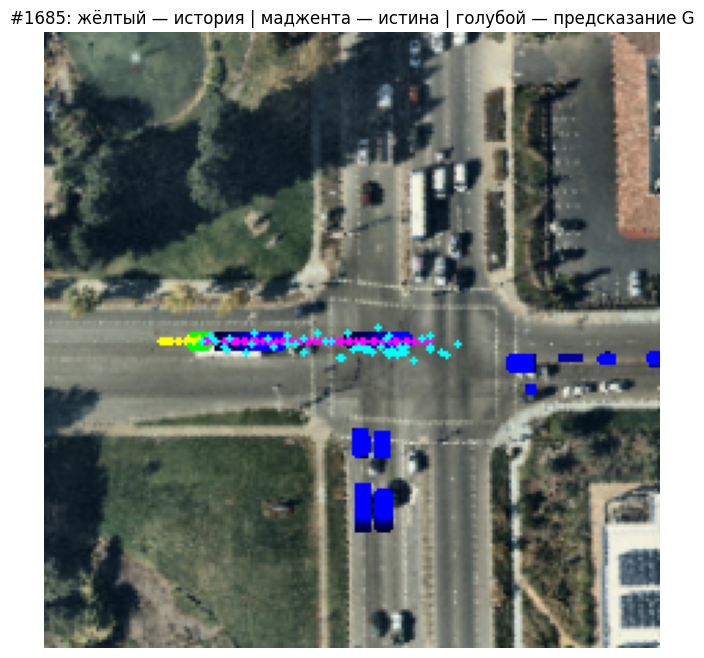

In [13]:
gen_resnet.eval()  # режим предсказания

IDX = 1500
for i in range(1500, min(3000, len(agent_dataset))):
    d = agent_dataset[i]
    hist_move = np.linalg.norm(d["history_positions"][-1] - d["history_positions"][0])
    fut_move = np.linalg.norm(d["target_positions"][-1] - d["target_positions"][0])
    if hist_move > 5 and fut_move > 20:   # ехал в истории И продолжит ехать
        IDX = i
        break
print(f"Пример #{IDX}: история {hist_move:.1f} м, будущее {fut_move:.1f} м")

# два «вида» одного кадра: box_debug — для ПРЕДСКАЗАНИЯ (на нём обучен G),
# спутник — только для ФОНА
data_model = agent_dataset[IDX]
cfg_sat = {**cfg, "raster_params": {**cfg["raster_params"],
           "map_type": "py_satellite",
           "satellite_map_key": "aerial_map/aerial_map.png",
           "semantic_map_key": "semantic_map/semantic_map.pb"}}
rasterizer_viz = build_rasterizer(cfg_sat, dm)
data_viz = AgentDataset(cfg_sat, zarr_dataset, rasterizer_viz)[IDX]

image_t = torch.from_numpy(data_model["image"]).unsqueeze(0).float().to(device)
with torch.no_grad():
    pred = gen_resnet(image_t)[0].cpu().numpy() * POS_SCALE  # (50, 2), метры

# рисуем ТОЛЬКО сырые координаты из data_viz (метры, без всякого POS_SCALE)
bg = rasterizer_viz.to_rgb(data_viz["image"].transpose(1, 2, 0))
m = data_viz["raster_from_agent"]  # матрица метры -> пиксели
draw_trajectory(bg, transform_points(data_viz["history_positions"], m), (255, 255, 0))
draw_trajectory(bg, transform_points(data_viz["target_positions"], m), TARGET_POINTS_COLOR)
draw_trajectory(bg, transform_points(pred, m), PREDICTED_POINTS_COLOR)

plt.figure(figsize=(8, 8))
plt.imshow(bg)
plt.title(f"#{IDX}: жёлтый — история | маджента — истина | голубой — предсказание G")
plt.axis("off")
plt.show()

## 5. Сохранение весов

In [14]:
with open(MODELS_DIR / "cfg.json", "w") as f:
    json.dump(cfg, f, indent=2)

registry = {
    "resnet": {"generator": "generator_resnet.pth", "discriminator": "discriminator_resnet.pth",
               "losses": "losses_resnet.npz", "curves": "curves_resnet.png"},
    "vae":    {"generator": "generator_vae.pth", "discriminator": "discriminator_vae.pth",
               "losses": "losses_vae.npz", "curves": "curves_vae.png"},
}

with open(MODELS_DIR / "registry.json", "w") as f:
    json.dump(registry, f, indent=2)

for p in sorted(MODELS_DIR.iterdir()):
    print(f"{p.name:26s} {p.stat().st_size / 1e6:.1f} МБ")

cfg.json                   0.0 МБ
curves_resnet.png          0.2 МБ
curves_vae.png             0.1 МБ
discriminator_resnet.pth   0.4 МБ
discriminator_vae.pth      0.4 МБ
generator_resnet.pth       47.5 МБ
generator_vae.pth          2.1 МБ
losses_resnet.npz          0.0 МБ
losses_vae.npz             0.1 МБ
registry.json              0.0 МБ
